# 01 - Análisis Exploratorio del Dataset


## Verificación de GPU

In [1]:
import torch

print("Versión de PyTorch:", torch.__version__)
print("GPU disponible:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Versión de PyTorch: 2.12.0+cpu
GPU disponible: False


In [8]:
import os

DATA_DIR = "../data/blood_cells/dataset2-master/dataset2-master/images"

print("Existe DATA_DIR:", os.path.exists(DATA_DIR))
print("Carpetas:", os.listdir(DATA_DIR))
print("Clases TRAIN:", os.listdir(os.path.join(DATA_DIR, "TRAIN")))
print("Clases TEST:", os.listdir(os.path.join(DATA_DIR, "TEST")))

Existe DATA_DIR: True
Carpetas: ['TEST', 'TEST_SIMPLE', 'TRAIN']
Clases TRAIN: ['EOSINOPHIL', 'LYMPHOCYTE', 'MONOCYTE', 'NEUTROPHIL']
Clases TEST: ['EOSINOPHIL', 'LYMPHOCYTE', 'MONOCYTE', 'NEUTROPHIL']


# EDA

## 1. Conteo de imágenes por clase

In [9]:
import os
import pandas as pd

train_dir = os.path.join(DATA_DIR, "TRAIN")
test_dir = os.path.join(DATA_DIR, "TEST")

def count_images_by_class(split_dir):
    records = []

    for class_name in sorted(os.listdir(split_dir)):
        class_path = os.path.join(split_dir, class_name)

        if os.path.isdir(class_path):
            images = [
                f for f in os.listdir(class_path)
                if f.lower().endswith((".jpg", ".jpeg", ".png"))
            ]

            records.append({
                "Clase": class_name,
                "Cantidad": len(images)
            })

    return pd.DataFrame(records)

train_counts = count_images_by_class(train_dir)
test_counts = count_images_by_class(test_dir)

print("Distribución en TRAIN")
display(train_counts)

print("Distribución en TEST")
display(test_counts)

Distribución en TRAIN


,Clase,Cantidad
0,EOSINOPHIL,2497
1,LYMPHOCYTE,2483
2,MONOCYTE,2478
3,NEUTROPHIL,2499


Distribución en TEST


,Clase,Cantidad
0,EOSINOPHIL,623
1,LYMPHOCYTE,620
2,MONOCYTE,620
3,NEUTROPHIL,624


## 2. Porcentaje por clase

In [10]:
train_counts["Porcentaje"] = (train_counts["Cantidad"] / train_counts["Cantidad"].sum() * 100).round(2)
test_counts["Porcentaje"] = (test_counts["Cantidad"] / test_counts["Cantidad"].sum() * 100).round(2)

print("TRAIN con porcentajes")
display(train_counts)

print("TEST con porcentajes")
display(test_counts)

TRAIN con porcentajes


,Clase,Cantidad,Porcentaje
0,EOSINOPHIL,2497,25.08
1,LYMPHOCYTE,2483,24.94
2,MONOCYTE,2478,24.89
3,NEUTROPHIL,2499,25.10


TEST con porcentajes


,Clase,Cantidad,Porcentaje
0,EOSINOPHIL,623,25.05
1,LYMPHOCYTE,620,24.93
2,MONOCYTE,620,24.93
3,NEUTROPHIL,624,25.09


In [11]:
distribution_summary = train_counts.merge(
    test_counts,
    on="Clase",
    suffixes=("_TRAIN", "_TEST")
)

distribution_summary

,Clase,Cantidad_TRAIN,Porcentaje_TRAIN,Cantidad_TEST,Porcentaje_TEST
0,EOSINOPHIL,2497,25.08,623,25.05
1,LYMPHOCYTE,2483,24.94,620,24.93
2,MONOCYTE,2478,24.89,620,24.93
3,NEUTROPHIL,2499,25.10,624,25.09


## 3. Gráficas de distribución por clase

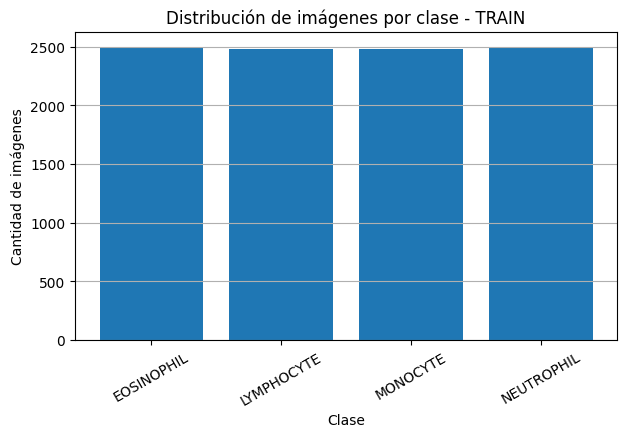

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.bar(train_counts["Clase"], train_counts["Cantidad"])
plt.xlabel("Clase")
plt.ylabel("Cantidad de imágenes")
plt.title("Distribución de imágenes por clase - TRAIN")
plt.xticks(rotation=30)
plt.grid(axis="y")
plt.savefig("../results/figures/eda_distribucion_train.png", bbox_inches="tight")
plt.show()

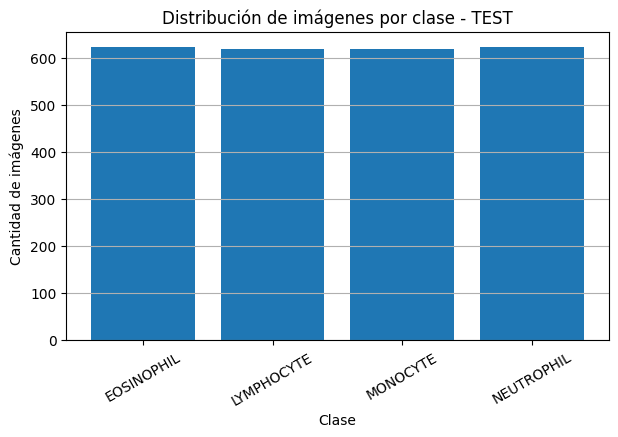

In [14]:
plt.figure(figsize=(7, 4))
plt.bar(test_counts["Clase"], test_counts["Cantidad"])
plt.xlabel("Clase")
plt.ylabel("Cantidad de imágenes")
plt.title("Distribución de imágenes por clase - TEST")
plt.xticks(rotation=30)
plt.grid(axis="y")
plt.savefig("../results/figures/eda_distribucion_test.png", bbox_inches="tight")
plt.show()

## 4. Comparación TRAIN vs TEST

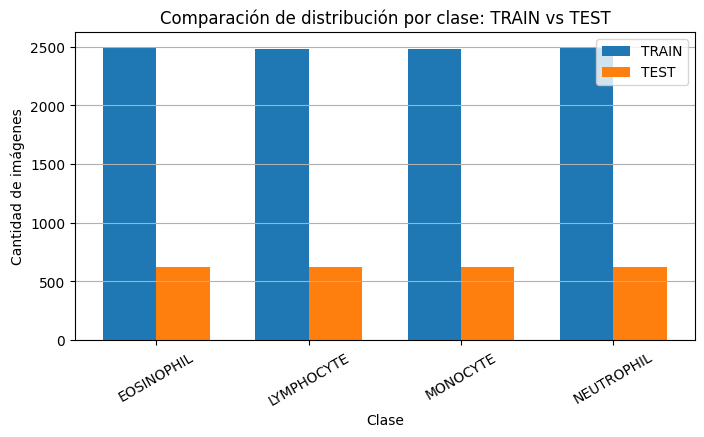

In [15]:
import numpy as np

x = np.arange(len(distribution_summary["Clase"]))
width = 0.35

plt.figure(figsize=(8, 4))
plt.bar(x - width/2, distribution_summary["Cantidad_TRAIN"], width, label="TRAIN")
plt.bar(x + width/2, distribution_summary["Cantidad_TEST"], width, label="TEST")

plt.xlabel("Clase")
plt.ylabel("Cantidad de imágenes")
plt.title("Comparación de distribución por clase: TRAIN vs TEST")
plt.xticks(x, distribution_summary["Clase"], rotation=30)
plt.legend()
plt.grid(axis="y")
plt.savefig("../results/figures/eda_distribucion_train_test.png", bbox_inches="tight")
plt.show()

## 5. Visualización de ejemplos por clase

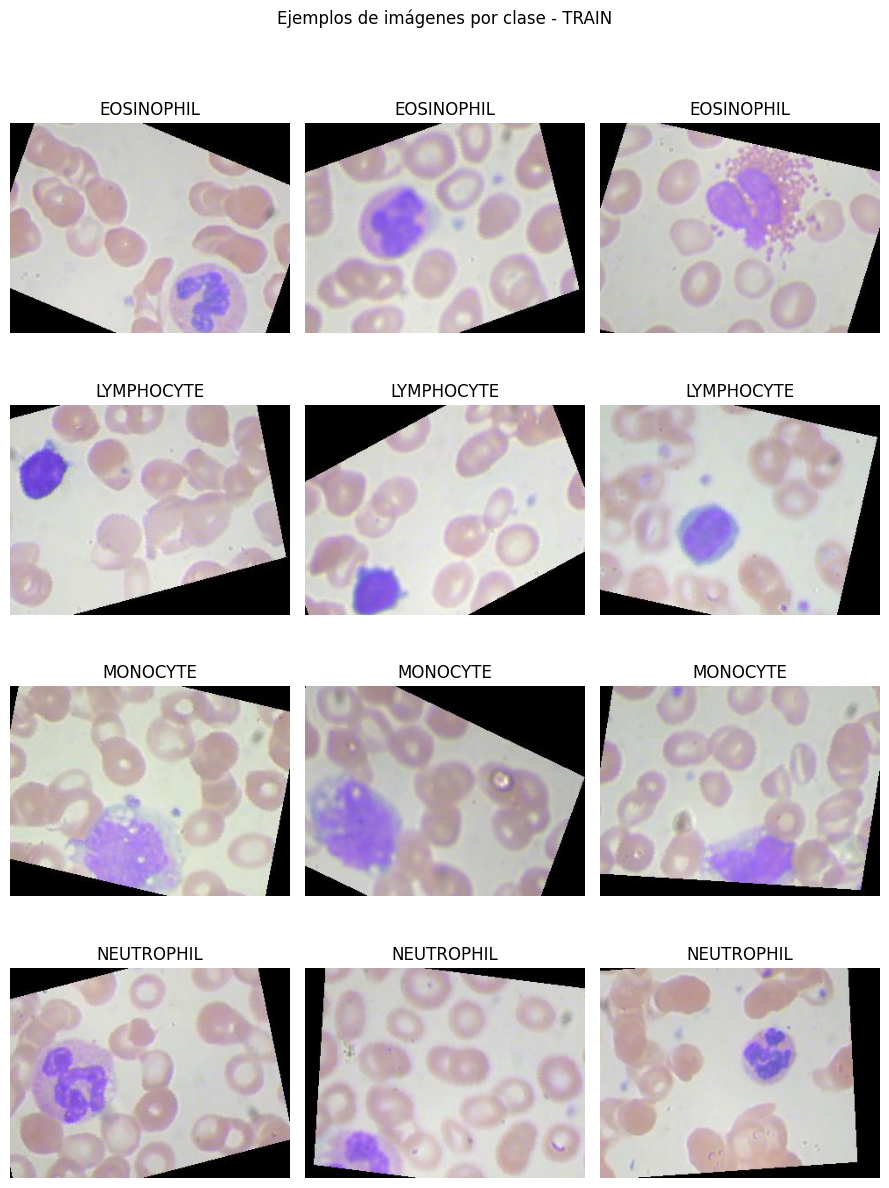

In [16]:
from PIL import Image
import random

def show_sample_images(split_dir, samples_per_class=3):
    class_names = sorted(os.listdir(split_dir))
    total_images = len(class_names) * samples_per_class

    plt.figure(figsize=(samples_per_class * 3, len(class_names) * 3))

    plot_idx = 1

    for class_name in class_names:
        class_path = os.path.join(split_dir, class_name)

        image_files = [
            f for f in os.listdir(class_path)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ]

        selected_images = random.sample(image_files, min(samples_per_class, len(image_files)))

        for img_name in selected_images:
            img_path = os.path.join(class_path, img_name)
            img = Image.open(img_path)

            plt.subplot(len(class_names), samples_per_class, plot_idx)
            plt.imshow(img)
            plt.title(class_name)
            plt.axis("off")

            plot_idx += 1

    plt.suptitle("Ejemplos de imágenes por clase - TRAIN", y=1.02)
    plt.tight_layout()
    plt.savefig("../results/figures/eda_ejemplos_por_clase.png", bbox_inches="tight")
    plt.show()

show_sample_images(train_dir, samples_per_class=3)

## 6. Verificar tamaño y modo de imágenes

In [17]:
from PIL import Image
import pandas as pd

def inspect_image_properties(split_dir, max_images_per_class=100):
    records = []

    for class_name in sorted(os.listdir(split_dir)):
        class_path = os.path.join(split_dir, class_name)

        image_files = [
            f for f in os.listdir(class_path)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ]

        image_files = image_files[:max_images_per_class]

        for img_name in image_files:
            img_path = os.path.join(class_path, img_name)

            with Image.open(img_path) as img:
                width, height = img.size

                records.append({
                    "Clase": class_name,
                    "Archivo": img_name,
                    "Ancho": width,
                    "Alto": height,
                    "Modo": img.mode,
                    "Formato": img.format
                })

    return pd.DataFrame(records)

image_properties = inspect_image_properties(train_dir, max_images_per_class=100)
image_properties.head()

,Clase,Archivo,Ancho,Alto,Modo,Formato
0,EOSINOPHIL,_0_1169.jpeg,320,240,RGB,JPEG
1,EOSINOPHIL,_0_1414.jpeg,320,240,RGB,JPEG
2,EOSINOPHIL,_0_207.jpeg,320,240,RGB,JPEG
3,EOSINOPHIL,_0_2142.jpeg,320,240,RGB,JPEG
4,EOSINOPHIL,_0_2370.jpeg,320,240,RGB,JPEG


### Resumen

In [18]:
image_properties[["Ancho", "Alto"]].describe()

,Ancho,Alto
count,400.0,400.0
mean,320.0,240.0
std,0.0,0.0
min,320.0,240.0
25%,320.0,240.0
50%,320.0,240.0
75%,320.0,240.0
max,320.0,240.0


### Modo de color

In [19]:
image_properties["Modo"].value_counts()

Modo
RGB    400
Name: count, dtype: int64

### Formato

In [20]:
image_properties["Formato"].value_counts()

Formato
JPEG    400
Name: count, dtype: int64

## 7. Gráfica de tamaños de imagen

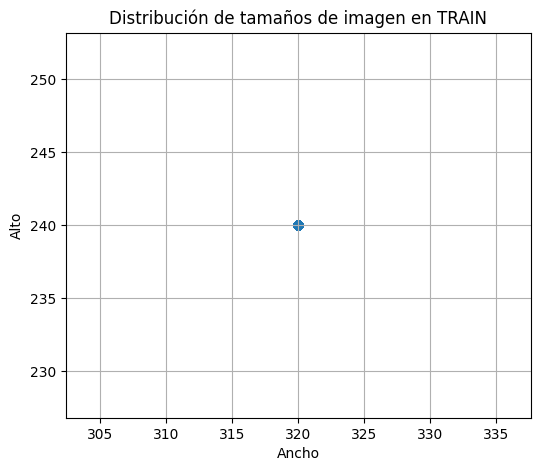

In [22]:
plt.figure(figsize=(6, 5))
plt.scatter(image_properties["Ancho"], image_properties["Alto"], alpha=0.5)
plt.xlabel("Ancho")
plt.ylabel("Alto")
plt.title("Distribución de tamaños de imagen en TRAIN")
plt.grid(True)
plt.savefig("../results/figures/eda_tamanios_imagenes.png", bbox_inches="tight")
plt.show()

## 8. Verificar imágenes corruptas

In [23]:
from PIL import Image

def find_corrupted_images(split_dir):
    corrupted = []

    for class_name in sorted(os.listdir(split_dir)):
        class_path = os.path.join(split_dir, class_name)

        image_files = [
            f for f in os.listdir(class_path)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ]

        for img_name in image_files:
            img_path = os.path.join(class_path, img_name)

            try:
                with Image.open(img_path) as img:
                    img.verify()
            except Exception as e:
                corrupted.append({
                    "Clase": class_name,
                    "Archivo": img_name,
                    "Error": str(e)
                })

    return pd.DataFrame(corrupted)

corrupted_train = find_corrupted_images(train_dir)
corrupted_test = find_corrupted_images(test_dir)

print("Imágenes corruptas en TRAIN:", len(corrupted_train))
print("Imágenes corruptas en TEST:", len(corrupted_test))

display(corrupted_train.head())
display(corrupted_test.head())

Imágenes corruptas en TRAIN: 0
Imágenes corruptas en TEST: 0


""


""


## 9. Guardar resumen del EDA en CSV

In [25]:
os.makedirs("../results/metrics", exist_ok=True)

train_counts.to_csv("../results/metrics/eda_train_distribution.csv", index=False)
test_counts.to_csv("../results/metrics/eda_test_distribution.csv", index=False)
distribution_summary.to_csv("../results/metrics/eda_distribution_summary.csv", index=False)
image_properties.to_csv("../results/metrics/eda_image_properties_sample.csv", index=False)